# Simulated cutoff–amplitude FWHM map

This notebook can either run the q1 20 µs echo cutoff simulation or load a saved result. It shows the aggregate plot collection, result tables, and a selected detuning–amplitude sweep. No hardware is used.

In [1]:
from dataclasses import replace
from datetime import datetime
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

def find_repo_root(start=Path.cwd().resolve()):
    for candidate in (start, *start.parents):
        if (candidate / 'Projects').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside opx1000-codes.')

REPO_ROOT = find_repo_root()
QUTIP_DIR = REPO_ROOT / 'Projects/shaped_pulse_spectroscopy/simulation/qutip'
if str(QUTIP_DIR) not in sys.path:
    sys.path.insert(0, str(QUTIP_DIR))

from parameters import SimulationParameters
from simulate_cutoff_amp_fwhm_map import cutoff_values, run_cutoff_map
from simulate_echo_lorentzian import plot_dataset, simulate_grid

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 120})
print('Repository:', REPO_ROOT)

Repository: C:\Users\owner\Developer\opx1000-codes


## Controls

The default only loads the completed result. Set `RUN_NEW_SWEEP=True` to execute all cutoff simulations. Set `RECOMPUTE_SELECTED_SWEEP=True` to recreate the raw xarray grid for one cutoff instead of only displaying its saved figure.

In [2]:
RUN_NEW_SWEEP = False
RECOMPUTE_SELECTED_SWEEP = False
SELECTED_CUTOFF_INDEX = 9  # zero-based; 9 is cutoff 0.002 in the saved run

SAVED_RESULT_DIR = REPO_ROOT / 'data/simulations/cutoff_amp_fwhm_map_20us_echo_q1'
NEW_RESULT_DIR = REPO_ROOT / 'data/simulations' / (
    'cutoff_amp_fwhm_map_20us_echo_q1_' + datetime.now().strftime('%Y%m%d_%H%M%S')
)

parameters = SimulationParameters(
    pulse_shape='root_lorentzian',
    lorentzian_length_in_ns=20_000,
    waveform_template_length_in_ns=20_000,
    lorentzian_peak_amplitude=0.15127819777954318,
    echo=True,
    min_amp_factor=0.01,
    max_amp_factor=1.0,
    amp_factor_points=16,
    amp_factor_spacing='log',
    frequency_span_in_mhz=1.0,
    frequency_points=81,
    qubit_name='q1',
    t1_in_us=30.87,
    t2_star_in_us=6.855588134130561,
    num_time_points=1000,
)
cutoffs = cutoff_values(0.002, 0.99, 10)

if RUN_NEW_SWEEP:
    parameters = replace(parameters, output_dir=NEW_RESULT_DIR)
    run_cutoff_map(parameters, cutoffs, NEW_RESULT_DIR)
    RESULT_DIR = NEW_RESULT_DIR
else:
    RESULT_DIR = SAVED_RESULT_DIR

if not RESULT_DIR.is_dir():
    raise FileNotFoundError(f'Result directory does not exist: {RESULT_DIR}')
print('Result directory:', RESULT_DIR)

Result directory: C:\Users\owner\Developer\opx1000-codes\data\simulations\cutoff_amp_fwhm_map_20us_echo_q1


## Load the saved results

In [3]:
manifest = json.loads((RESULT_DIR / 'manifest.json').read_text(encoding='utf-8'))
fit_results = pd.read_csv(RESULT_DIR / 'cutoff_amp_fwhm_map_fit_results.csv')
summary = pd.Series({
    'created_at': manifest['created_at'],
    'duration_s': manifest['duration_s'],
    'completed_cutoffs': manifest['completed_runs'],
    'fit_rows': len(fit_results),
    'valid_fwhm_rows': int(fit_results.fwhm_hz.notna().sum()),
    'T2_star_us': manifest['parameters']['t2_star_in_us'],
    'T2_star_FWHM_limit_kHz': fit_results.t2_star_fwhm_limit_hz.dropna().iloc[0] / 1e3,
}, name='value')
display(summary.to_frame())
display(fit_results.sort_values(['cutoff', 'full_amp_v']).reset_index(drop=True))

,value
created_at,2026-07-13T12:14:22.721089+03:00
duration_s,500.514081
completed_cutoffs,10
fit_rows,160
valid_fwhm_rows,155
T2_star_us,6.855588
T2_star_FWHM_limit_kHz,46.430719


,run_index,cutoff,qubit,amp_prefactor,full_amp_v,rabi_frequency_mhz,gaussian_center_hz,fwhm_hz,fwhm_mhz,t2_star_s,...,fit_amplitude,fit_abs_amplitude,fit_r_squared,fit_model,positive_fwhm_hz,positive_fit_abs_amplitude,positive_fit_r_squared,negative_fwhm_hz,negative_fit_abs_amplitude,negative_fit_r_squared
0,10,0.002,q1,0.010000,0.001513,0.125000,1.113342,68709.021954,0.068709,0.000007,...,-0.002695,0.002695,0.909338,superposition,71534.952456,0.002536,0.909338,68709.021954,0.002695,0.909338
1,10,0.002,q1,0.013594,0.002056,0.169920,-21.847981,69459.028500,0.069459,0.000007,...,-0.010819,0.010819,0.909419,superposition,70736.647574,0.010526,0.909419,69459.028500,0.010819,0.909419
2,10,0.002,q1,0.018478,0.002795,0.230981,8.820692,69975.038426,0.069975,0.000007,...,-0.239914,0.239914,0.909803,superposition,70079.819097,0.239373,0.909803,69975.038426,0.239914,0.909803
3,10,0.002,q1,0.025119,0.003800,0.313986,3.862841,69906.287542,0.069906,0.000007,...,-0.299287,0.299287,0.910372,superposition,70060.859577,0.298287,0.910372,69906.287542,0.299287,0.910372
4,10,0.002,q1,0.034145,0.005165,0.426819,0.877500,69541.501050,0.069542,0.000007,...,-0.114470,0.114470,0.911397,superposition,70286.841291,0.112618,0.911397,69541.501050,0.114470,0.911397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,1,0.990,q1,0.292864,0.044304,3.660806,68831.723636,757.124748,0.000757,0.000007,...,127461.543333,127461.543333,0.866657,superposition,757.124748,127461.543333,0.866657,308296.187868,0.003113,0.866657
156,1,0.990,q1,0.398107,0.060225,4.976340,-64.403005,158244.889735,0.158245,0.000007,...,-0.000219,0.000219,0.969317,separate,NaN,NaN,NaN,158244.889735,0.000219,0.969317
157,1,0.990,q1,0.541170,0.081867,6.764619,76812.688498,291773.965280,0.291774,0.000007,...,-0.000690,0.000690,0.953894,separate,NaN,NaN,NaN,291773.965280,0.000690,0.953894
158,1,0.990,q1,0.735642,0.111287,9.195528,150496.949116,105105.843940,0.105106,0.000007,...,-0.000073,0.000073,0.977410,separate,NaN,NaN,NaN,105105.843940,0.000073,0.977410


## Aggregate plot collection

The middle image contains reciprocal FWHM resolution and `resolution * fit signal`, both on logarithmic cutoff/amplitude axes.

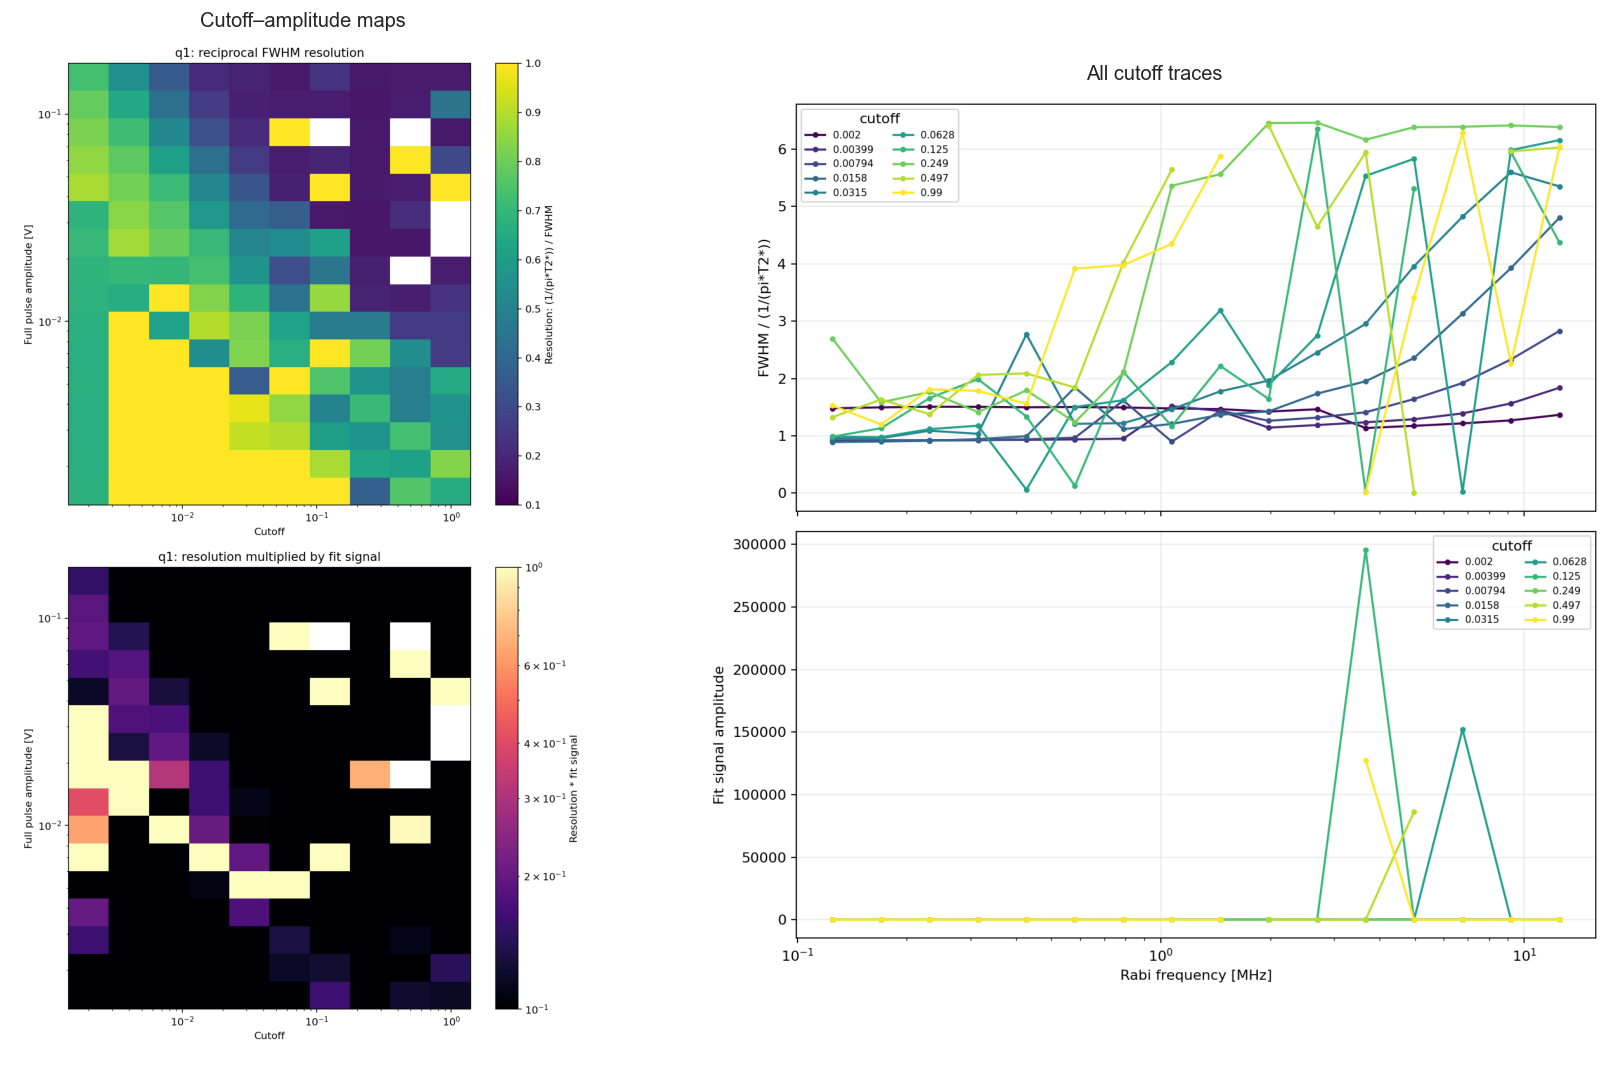

In [4]:
plot_files = [
    ('Cutoff–amplitude maps', RESULT_DIR / 'cutoff_amp_fwhm_map_fwhm_heatmap.png'),
    ('All cutoff traces', RESULT_DIR / 'cutoff_amp_fwhm_map_per_cutoff_traces.png'),
]
fig, axes = plt.subplots(1, 2, figsize=(15, 9))
for axis, (title, path) in zip(axes, plot_files):
    if path.exists():
        axis.imshow(plt.imread(path))
    else:
        axis.text(0.5, 0.5, f'Missing: {path.name}', ha='center', va='center')
    axis.set_title(title)
    axis.axis('off')
fig.tight_layout()
plt.show()

## Selected detuning–amplitude sweep

With the default setting this displays the saved sweep image. Recomputing additionally exposes `selected_ds`, the fitted xarray dataset, and saves it as NetCDF inside the result directory.

Selected cutoff: 0.002


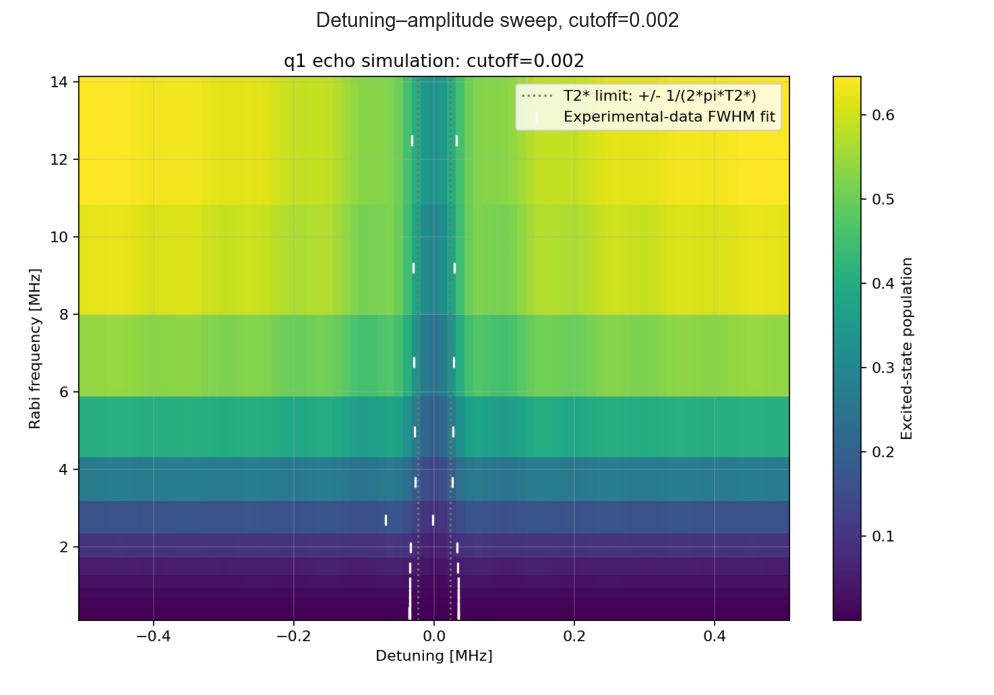

In [5]:
runs = manifest['runs']
if not 0 <= SELECTED_CUTOFF_INDEX < len(runs):
    raise IndexError(f'SELECTED_CUTOFF_INDEX must be between 0 and {len(runs) - 1}.')
selected_run = runs[SELECTED_CUTOFF_INDEX]
selected_cutoff = float(selected_run['cutoff'])
selected_parameters = replace(parameters, cutoff=selected_cutoff)
print(f"Selected cutoff: {selected_cutoff:.6g}")

if RECOMPUTE_SELECTED_SWEEP:
    selected_ds = simulate_grid(selected_parameters)
    netcdf_path = RESULT_DIR / f'selected_cutoff_{selected_cutoff:.3e}.nc'
    selected_ds.to_netcdf(netcdf_path)
    figure_path = plot_dataset(
        selected_ds,
        RESULT_DIR / 'individual_figures',
        filename=f'notebook_cutoff_{selected_cutoff:.3e}.png',
        title=f'q1 20 us echo simulation: cutoff={selected_cutoff:.3g}',
    )
else:
    selected_ds = None
    figure_path = RESULT_DIR / 'individual_figures' / (
        f"cutoff_{int(selected_run['run_index']):02d}_{selected_cutoff:.3e}.png"
    )

fig, axis = plt.subplots(figsize=(11, 7))
axis.imshow(plt.imread(figure_path))
axis.axis('off')
axis.set_title(f'Detuning–amplitude sweep, cutoff={selected_cutoff:.6g}')
plt.show()

## FWHM and signal across amplitude for the selected cutoff

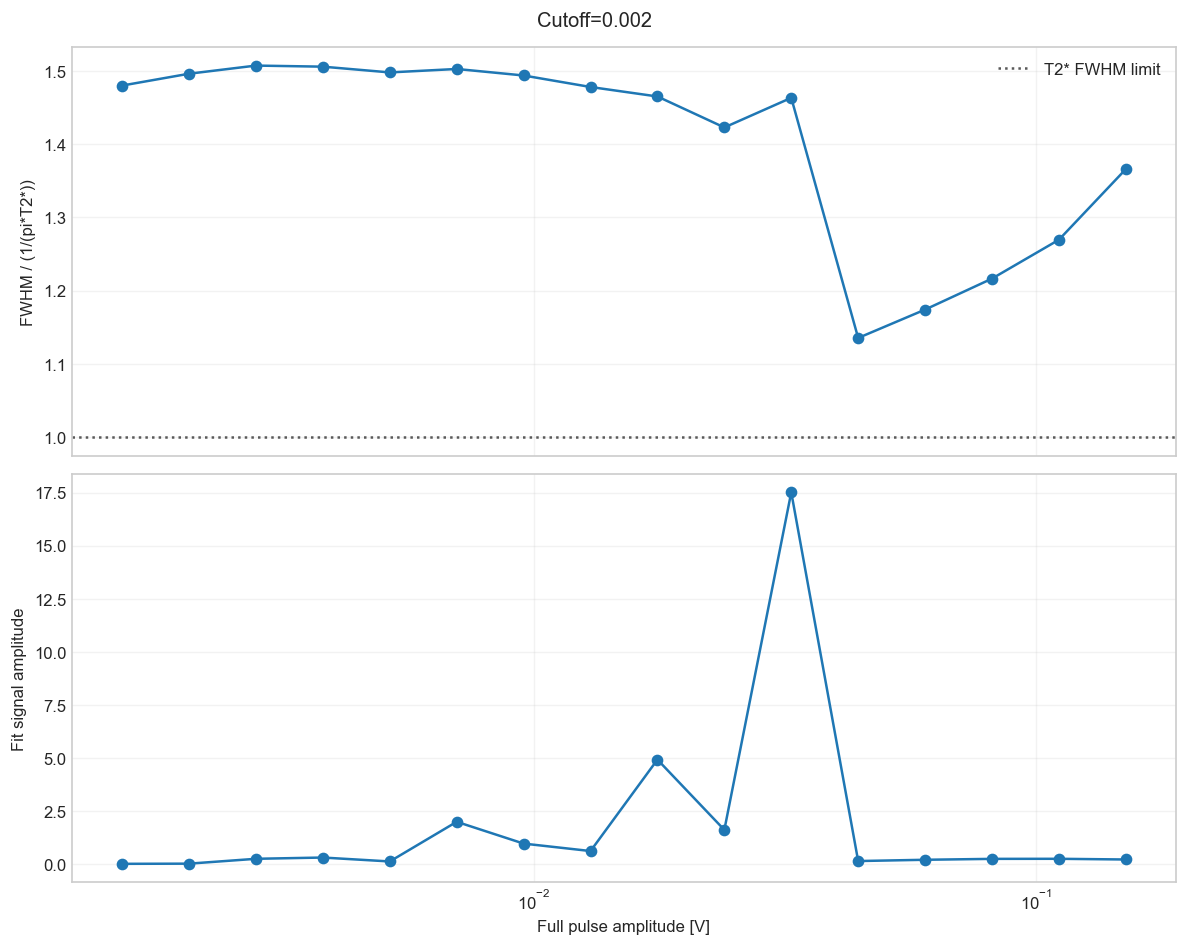

,run_index,cutoff,qubit,amp_prefactor,full_amp_v,rabi_frequency_mhz,gaussian_center_hz,fwhm_hz,fwhm_mhz,t2_star_s,...,fit_amplitude,fit_abs_amplitude,fit_r_squared,fit_model,positive_fwhm_hz,positive_fit_abs_amplitude,positive_fit_r_squared,negative_fwhm_hz,negative_fit_abs_amplitude,negative_fit_r_squared
0,10,0.002,q1,0.010000,0.001513,0.125000,1.113342,68709.021954,0.068709,0.000007,...,-0.002695,0.002695,0.909338,superposition,71534.952456,0.002536,0.909338,68709.021954,0.002695,0.909338
1,10,0.002,q1,0.013594,0.002056,0.169920,-21.847981,69459.028500,0.069459,0.000007,...,-0.010819,0.010819,0.909419,superposition,70736.647574,0.010526,0.909419,69459.028500,0.010819,0.909419
2,10,0.002,q1,0.018478,0.002795,0.230981,8.820692,69975.038426,0.069975,0.000007,...,-0.239914,0.239914,0.909803,superposition,70079.819097,0.239373,0.909803,69975.038426,0.239914,0.909803
3,10,0.002,q1,0.025119,0.003800,0.313986,3.862841,69906.287542,0.069906,0.000007,...,-0.299287,0.299287,0.910372,superposition,70060.859577,0.298287,0.910372,69906.287542,0.299287,0.910372
4,10,0.002,q1,0.034145,0.005165,0.426819,0.877500,69541.501050,0.069542,0.000007,...,-0.114470,0.114470,0.911397,superposition,70286.841291,0.112618,0.911397,69541.501050,0.114470,0.911397
5,10,0.002,q1,0.046416,0.007022,0.580199,0.775768,69759.764088,0.069760,0.000007,...,-1.984172,1.984172,0.913222,superposition,69837.445348,1.980739,0.913222,69759.764088,1.984172,0.913222
6,10,0.002,q1,0.063096,0.009545,0.788697,5.567451,69347.335384,0.069347,0.000007,...,-0.956794,0.956794,0.916486,superposition,69636.765009,0.950417,0.916486,69347.335384,0.956794,0.916486
7,10,0.002,q1,0.085770,0.012975,1.072120,0.634551,68617.887417,0.068618,0.000007,...,-0.605241,0.605241,0.921929,superposition,69423.177438,0.593360,0.921929,68617.887417,0.605241,0.921929
8,10,0.002,q1,0.116591,0.017638,1.457393,-2.191677,68016.502383,0.068017,0.000007,...,-4.915899,4.915899,0.930342,superposition,68179.880393,4.893673,0.930342,68016.502383,4.915899,0.930342
9,10,0.002,q1,0.158489,0.023976,1.981116,0.210024,66053.707802,0.066054,0.000007,...,-1.602932,1.602932,0.940899,superposition,66811.756574,1.561319,0.940899,66053.707802,1.602932,0.940899


In [6]:
selected_rows = fit_results.loc[
    np.isclose(fit_results.cutoff, selected_cutoff)
].sort_values('full_amp_v')

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(selected_rows.full_amp_v, selected_rows.fwhm_t2_star_units, 'o-')
axes[0].axhline(1, color='0.35', linestyle=':', label='T2* FWHM limit')
axes[0].set_ylabel('FWHM / (1/(pi*T2*))')
axes[0].legend()
axes[1].plot(selected_rows.full_amp_v, selected_rows.fit_abs_amplitude, 'o-')
axes[1].set_ylabel('Fit signal amplitude')
axes[1].set_xlabel('Full pulse amplitude [V]')
for axis in axes:
    axis.set_xscale('log')
    axis.grid(alpha=0.25)
fig.suptitle(f'Cutoff={selected_cutoff:.6g}')
fig.tight_layout()
plt.show()
display(selected_rows.reset_index(drop=True))